<a href="https://colab.research.google.com/github/emyjayo1815-del/Data110_Fall_2025/blob/main/Final_Project_Emilie_Ortiz_7-29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Uploading the Data**

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
import seaborn as sns

In [44]:
df=pd.read_csv('/content/drive/MyDrive/Final Project/Traffic_Violations_20251207.csv')
df.head()

/tmp/ipython-input-1190981593.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/Final Project/Traffic_Violations_20251207.csv')


,SeqID,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
0,61da5ab2-eb64-494b-ae06-035018aa1249,12/06/2025,06:54:00,MCP,"5th District, Germantown",PARKING WHERE PROHIBITED BY OFFICIAL SIGNS,MATENY RD/EAGLES ROOST DR,39.161812,-77.269268,No,...,21-1003(aa),Transportation Article,False,OTHER,F,GERMANTOWN,MD,MD,A - Marked Patrol,"(39.1618116666667, -77.2692683333333)"
1,eee7e950-a12f-47bb-ab5a-335ec4492b96,12/06/2025,06:30:00,MCP,"5th District, Germantown",DRIVER FAILURE TO STOP AT STOP SIGN LINE,DAIRYMAID DR/MATENY RD,39.147747,-77.270880,No,...,21-707(a),Transportation Article,False,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.1477466666667, -77.27088)"
2,28c4f7cd-5c8c-4c32-8e4d-0c57e76a362d,12/06/2025,04:36:00,MCP,"5th District, Germantown",DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,RIDGE RD @ HENDERSON CORNER,39.205472,-77.243404,No,...,21-201(a1),Transportation Article,False,BLACK,M,GERMANTOWN,MD,MD,A - Marked Patrol,"(39.2054725, -77.2434041666667)"
3,78500af8-3680-468f-be93-90e4cd233e0f,12/06/2025,04:34:00,MCP,"3rd District, Silver Spring",PERSON DRIVING MOTOR VEHICLE ON HIGHWAY OR PUB...,SB 650 AT 29,39.045493,-76.991062,No,...,16-303(c),Transportation Article,False,BLACK,M,ALEXANDRIA,VA,MD,A - Marked Patrol,"(39.0454935, -76.9910615)"
4,78500af8-3680-468f-be93-90e4cd233e0f,12/06/2025,04:34:00,MCP,"3rd District, Silver Spring","DRIVING WHILE LIC. SUSP. UNDER 16-203, 16-206A...",SB 650 AT 29,39.045493,-76.991062,No,...,16-303(h),Transportation Article,False,BLACK,M,ALEXANDRIA,VA,MD,A - Marked Patrol,"(39.0454935, -76.9910615)"


**Reviewing the Data**

In [46]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2070175 entries, 0 to 2070174
Data columns (total 43 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   SeqID                    object 
 1   Date Of Stop             object 
 2   Time Of Stop             object 
 3   Agency                   object 
 4   SubAgency                object 
 5   Description              object 
 6   Location                 object 
 7   Latitude                 float64
 8   Longitude                float64
 9   Accident                 object 
 10  Belts                    object 
 11  Personal Injury          object 
 12  Property Damage          object 
 13  Fatal                    object 
 14  Commercial License       object 
 15  HAZMAT                   object 
 16  Commercial Vehicle       object 
 17  Alcohol                  object 
 18  Work Zone                object 
 19  Search Conducted         object 
 20  Search Disposition       object 
 21  Search O

,Latitude,Longitude,Year
count,2.070175e+06,2.070175e+06,2.059530e+06
mean,3.613793e+01,-7.130142e+01,2.007615e+03
std,1.032079e+01,2.036340e+01,8.489640e+01
min,0.000000e+00,-1.512560e+02,0.000000e+00
25%,3.901642e+01,-7.719294e+01,2.003000e+03
50%,3.906618e+01,-7.708753e+01,2.008000e+03
75%,3.913717e+01,-7.702696e+01,2.013000e+03
max,4.154316e+01,3.906444e+01,9.999000e+03


**Cleaning the Data**

In [47]:
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2070175 entries, 0 to 2070174
Data columns (total 43 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   SeqID                    object 
 1   Date Of Stop             object 
 2   Time Of Stop             object 
 3   Agency                   object 
 4   SubAgency                object 
 5   Description              object 
 6   Location                 object 
 7   Latitude                 float64
 8   Longitude                float64
 9   Accident                 object 
 10  Belts                    object 
 11  Personal Injury          object 
 12  Property Damage          object 
 13  Fatal                    object 
 14  Commercial License       object 
 15  HAZMAT                   object 
 16  Commercial Vehicle       object 
 17  Alcohol                  object 
 18  Work Zone                object 
 19  Search Conducted         object 
 20  Search Disposition       object 
 21  Search O

**Creating Map with Latitude and Longitude Fields**

In [48]:
center_lat=cleaned_df ['Latitude'].median()
center_lon=cleaned_df ['Longitude'].median()
heat_data=cleaned_df [ ['Latitude', 'Longitude']]. values
m=folium.Map(location=[center_lat,center_lon],zoom_start=12)
HeatMap(heat_data).add_to(m)

m.path='myfirstmap.html'
m.save('myfirstmap.html')


**Creating histograms or Year Distribution**

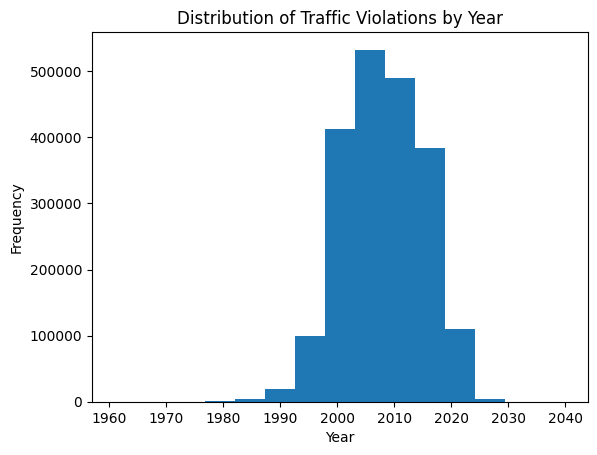

In [49]:
from pandas.tseries.offsets import YearBegin
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])
cleaned_df = cleaned_df[(cleaned_df['Year'] >= 1960) & (cleaned_df['Year'] <= 2040)]
plt.hist(cleaned_df ['Year'],bins=15)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Traffic Violations by Year')
plt.show ()


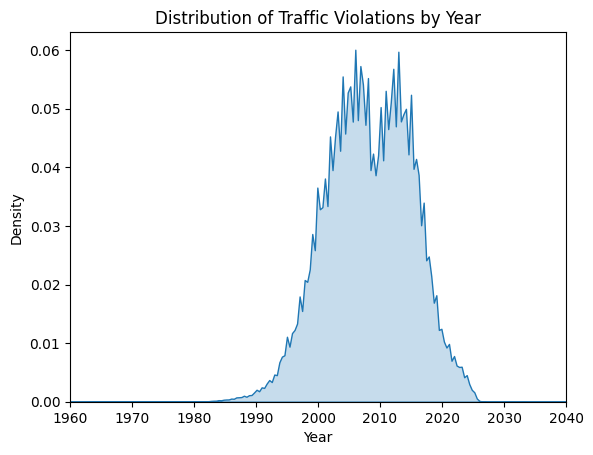

In [50]:
sns.kdeplot(cleaned_df['Year'],fill=True)
plt.xlabel('Year')
plt.ylabel('Density')
plt.title('Distribution of Traffic Violations by Year')
plt.xlim(1960,2040)
plt.show ()

**Bar Graph to review Number of Traffic Violations per year**

/tmp/ipython-input-2052712418.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_df['Year'] = md_df['Year'].astype(int)


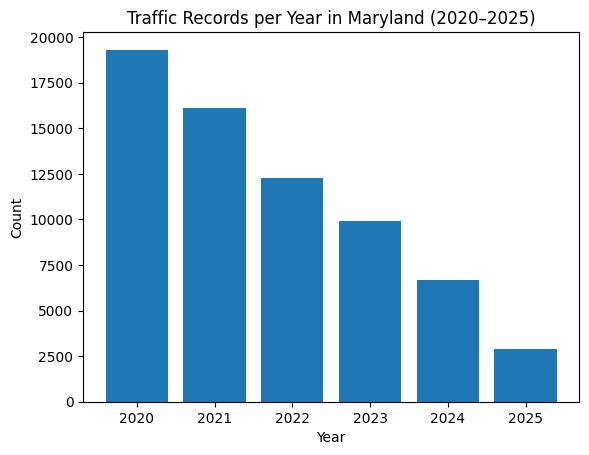

In [51]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Remove rows with missing coordinates
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter Maryland only
md_df = cleaned_df[cleaned_df['State'] == 'MD']

# Make sure Year is numeric
md_df['Year'] = md_df['Year'].astype(int)

# Filter years 2020–2025
md_df = md_df[(md_df['Year'] >= 2020) & (md_df['Year'] <= 2025)]

# Count records per year
year_counts = md_df['Year'].value_counts().sort_index()

# Plot
plt.bar(year_counts.index, year_counts.values)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Traffic Records per Year in Maryland (2020–2025)')
plt.show()

**Bar Graph to review Number of Traffic Violations per Month of 2024**

/tmp/ipython-input-3282178450.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])


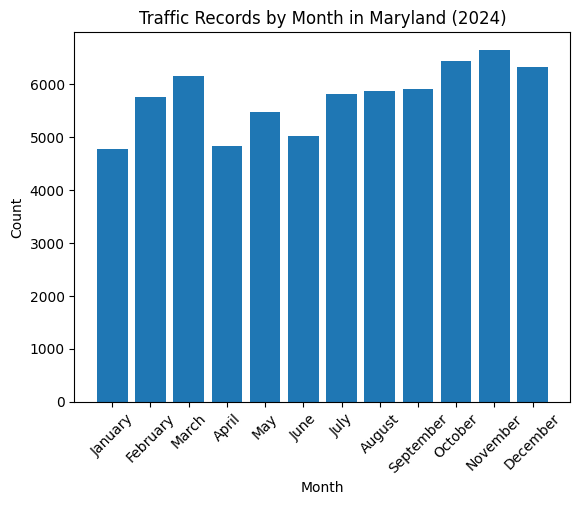

In [52]:
from matplotlib import pyplot as plt
import pandas as pd
import calendar

# Clean data
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter MD only
md_df = cleaned_df[cleaned_df['State'] == 'MD']

# Convert Date column to datetime
md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])

# Filter only 2024
md_2024 = md_df[md_df['Date Of Stop'].dt.year == 2024]

# Group by month (numeric)
month_counts = md_2024['Date Of Stop'].dt.month.value_counts().sort_index()

# Convert month numbers to month names
month_counts.index = [calendar.month_name[m] for m in month_counts.index]

# Plot
plt.bar(month_counts.index, month_counts.values)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Traffic Records by Month in Maryland (2024)')
plt.xticks(rotation=45)
plt.show()

**Bar Graph to review Number of Traffic Violations per Hour in November 2024**

/tmp/ipython-input-1278930431.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])
/tmp/ipython-input-1278930431.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_nov_2024['Hour'] = time_str.str[:2].astype(int)


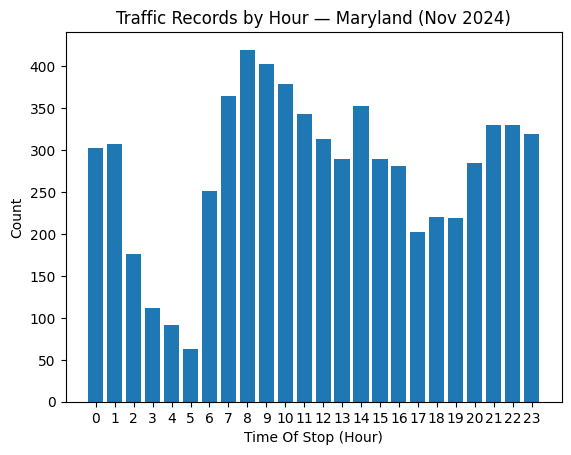

In [57]:
from matplotlib import pyplot as plt
import pandas as pd
import calendar

# Clean data
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter MD only
md_df = cleaned_df[cleaned_df['State'] == 'MD']

# Convert Date column to datetime
md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])

# Filter November 2024
md_nov_2024 = md_df[
    (md_df['Date Of Stop'].dt.year == 2024) &
    (md_df['Date Of Stop'].dt.month == 11)
]
# Convert Time Of Stop to hour (handles 930 -> 09:30, 1430 -> 14:30)
time_str = md_nov_2024['Time Of Stop'].astype(str).str.zfill(4)
md_nov_2024['Hour'] = time_str.str[:2].astype(int)

# Count by hour
hour_counts = md_nov_2024['Hour'].value_counts().sort_index()
hour_counts = hour_counts.reindex(range(24), fill_value=0)

# Plot
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel('Time Of Stop (Hour)')
plt.ylabel('Count')
plt.title('Traffic Records by Hour — Maryland (Nov 2024)')
plt.xticks(range(24))
plt.show()


**Line chart of type of Traffic Violatis in November 2024**

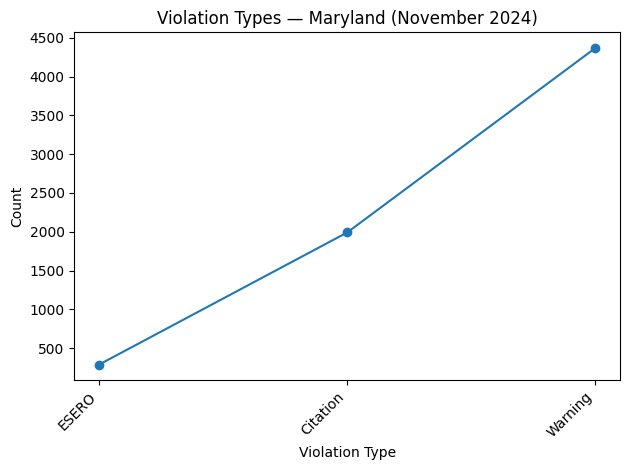

In [71]:
from matplotlib import pyplot as plt
import pandas as pd

# Clean data
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter MD only
md_df = cleaned_df[cleaned_df['State'] == 'MD'].copy()

# Convert Date column to datetime
md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])

# Filter November 2024
md_nov_warning = md_df[
    (md_df['Date Of Stop'].dt.year == 2024) &
    (md_df['Date Of Stop'].dt.month == 11)
]

# Count by Violation Type
violationtype_counts = md_nov_warning['Violation Type'].value_counts()

# OPTIONAL: sort for cleaner line flow
violationtype_counts = violationtype_counts.sort_values()

# Plot line chart
plt.plot(
    violationtype_counts.index,
    violationtype_counts.values,
    marker='o'
)

plt.xlabel('Violation Type')
plt.ylabel('Count')
plt.title('Violation Types — Maryland (November 2024)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Bar chart Warning Violations of November 2024 by Race**

/tmp/ipython-input-1102336369.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])


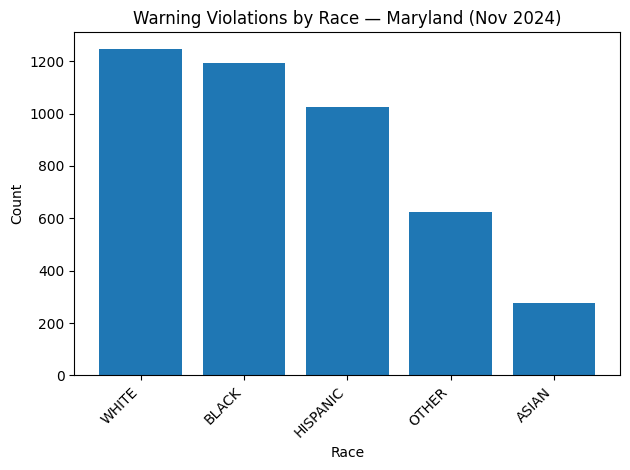

In [61]:
from matplotlib import pyplot as plt
import pandas as pd

# Clean data
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter MD only
md_df = cleaned_df[cleaned_df['State'] == 'MD']

# Convert Date column to datetime
md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])

# Filter November 2024 + Violation Type = Warning
md_nov_warning = md_df[
    (md_df['Date Of Stop'].dt.year == 2024) &
    (md_df['Date Of Stop'].dt.month == 11) &
    (md_df['Violation Type'].str.lower() == 'warning')
]

# Count by Race
race_counts = md_nov_warning['Race'].value_counts()

# Plot
plt.bar(race_counts.index, race_counts.values)
plt.xlabel('Race')
plt.ylabel('Count')
plt.title('Warning Violations by Race — Maryland (Nov 2024)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Bar chart Warning Violations of November 2024 by Gender**

/tmp/ipython-input-1523094626.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])


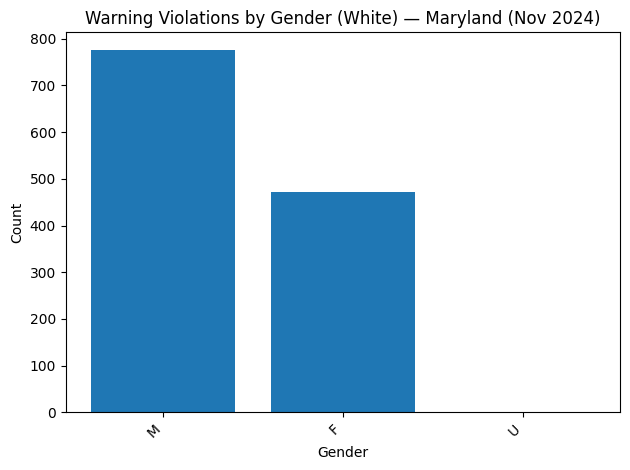

In [62]:
from matplotlib import pyplot as plt
import pandas as pd

# Clean data
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter MD only
md_df = cleaned_df[cleaned_df['State'] == 'MD']

# Convert Date column to datetime
md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])

# Filter November 2024 + Violation Type = Warning + Race = White
md_nov_warning = md_df[
    (md_df['Date Of Stop'].dt.year == 2024) &
    (md_df['Date Of Stop'].dt.month == 11) &
    (md_df['Violation Type'].str.lower() == 'warning') &
    (md_df['Race'].str.lower() == 'white')
]

# Count by Gender
gender_counts = md_nov_warning['Gender'].value_counts()

# Plot
plt.bar(gender_counts.index, gender_counts.values)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Warning Violations by Gender (White) — Maryland (Nov 2024)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Bar chart Warning Violations of November 2024 by Race and Gender **

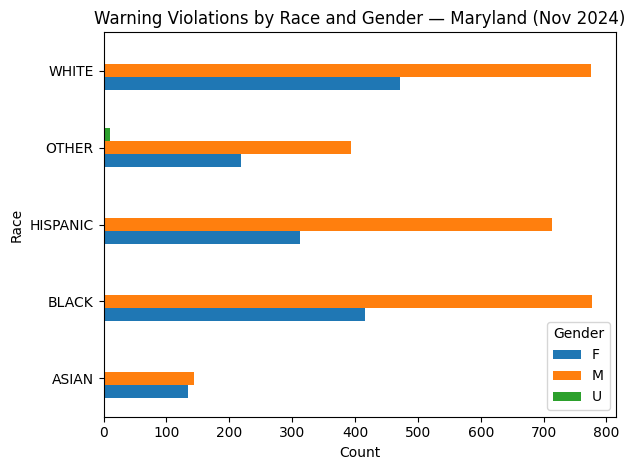

In [75]:
from matplotlib import pyplot as plt
import pandas as pd

# Clean data
cleaned_df = df.dropna(subset=['Latitude', 'Longitude'])

# Filter MD only
md_df = cleaned_df[cleaned_df['State'] == 'MD'].copy()

# Convert Date column to datetime
md_df['Date Of Stop'] = pd.to_datetime(md_df['Date Of Stop'])

# Filter November 2024 + Violation Type = Warning
md_nov_warning = md_df[
    (md_df['Date Of Stop'].dt.year == 2024) &
    (md_df['Date Of Stop'].dt.month == 11) &
    (md_df['Violation Type'].str.lower() == 'warning')
]

# Group by Race and Gender
grouped = md_nov_warning.groupby(['Race', 'Gender']).size().unstack(fill_value=0)

# Plot horizontal bars
grouped.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Race')
plt.title('Warning Violations by Race and Gender — Maryland (Nov 2024)')
plt.tight_layout()
plt.show()

import pandas as pd
import scaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from joypy import joyplot

In [86]:
!pip install joypy

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from joypy import joyplot

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Final Project/Traffic_Violations_20251207.csv')
df.head()